# **Предсказание оттока клиентов**

Есть данные о клиентах телеком компании как пол, возраст, длительность сотрудничества, потраченные деньги на подписку и т.д. Необходимо определить, уйдет ли клиент или нет. Для этого используются логистическая регрессия, которая обучается на наборе данных для обучения train, и предсказывает, уйдет ли клиент на датасете test.

## Загрузка данных. Исследование.

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 8.34MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 4.75MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 33.8MB/s]


In [4]:
data = pd.read_csv('./train.csv')

test = pd.read_csv('test.csv')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [6]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              1761 non-null   int64  
 1   MonthlySpending           1761 non-null   float64
 2   TotalSpent                1761 non-null   object 
 3   Sex                       1761 non-null   object 
 4   IsSeniorCitizen           1761 non-null   int64  
 5   HasPartner                1761 non-null   object 
 6   HasChild                  1761 non-null   object 
 7   HasPhoneService           1761 non-null   object 
 8   HasMultiplePhoneNumbers   1761 non-null   object 
 9   HasInternetService        1761 non-null   object 
 10  HasOnlineSecurityService  1761 non-null   object 
 11  HasOnlineBackup           1761 non-null   object 
 12  HasDeviceProtection       1761 non-null   object 
 13  HasTechSupportAccess      1761 non-null   object 
 14  HasOnlin

In [8]:
data.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
3521,5,48.65,235.2,Male,0,No,Yes,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),0
4412,33,107.55,3645.5,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,0
2250,70,51.05,3635.15,Male,0,Yes,No,No,No phone service,DSL,No,Yes,Yes,Yes,No,Yes,One year,Yes,Bank transfer (automatic),0
2432,62,96.75,6125.4,Male,0,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,One year,Yes,Electronic check,1
5232,27,66.15,1874.45,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,One year,No,Mailed check,0


В нашем распоряжении таблица с данными о клиентах телеком компании. У нас есть 20 признаков для каждого клиента, всего клиентов 5282.

Признак TotalSpent переведем в тип float.

In [9]:
data[data['TotalSpent'] == ' ']['TotalSpent'].count()

np.int64(9)

In [10]:
test[test['TotalSpent'] == ' ']['TotalSpent'].count()

np.int64(2)

Всего 9 строчек с незаполненными данными в признаке TotalSpent, поэтому удалим их.

В случае с тестовой выборкой заполним медианным значением, чтобы оставить нужный размер таблицы.

In [11]:
data.loc[data['TotalSpent'] == ' ', 'TotalSpent'] = pd.NA

data.dropna(inplace=True)

test.loc[test['TotalSpent'] == ' ', 'TotalSpent'] = 0

In [12]:
data['TotalSpent'] = data['TotalSpent'].astype('float')
test['TotalSpent'] = test['TotalSpent'].astype('float')

In [13]:
test.loc[test['TotalSpent']==0,'TotalSpent'] = test['TotalSpent'].median()

In [14]:
data['HasPartner'].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
data['HasChild'].unique()

array(['Yes', 'No'], dtype=object)

In [16]:
data['HasPhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [17]:
data['HasMultiplePhoneNumbers'].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [18]:
data['HasInternetService'].unique()

array(['No', 'Fiber optic', 'DSL'], dtype=object)

In [19]:
data['HasOnlineSecurityService'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [20]:
data['HasOnlineBackup'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [21]:
data['HasDeviceProtection'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [22]:
data['HasTechSupportAccess'].unique()

array(['No internet service', 'Yes', 'No'], dtype=object)

In [23]:
data['HasOnlineTV'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [24]:
data['HasMovieSubscription'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [25]:
data['HasContractPhone'].unique()

array(['One year', 'Two year', 'Month-to-month'], dtype=object)

In [26]:
data['IsBillingPaperless'].unique()

array(['No', 'Yes'], dtype=object)

In [27]:
data['PaymentMethod'].unique()

array(['Mailed check', 'Credit card (automatic)', 'Electronic check',
       'Bank transfer (automatic)'], dtype=object)

In [28]:
data['Churn'].unique()

array([0, 1])

Явных пропусков нет, неявные были в столбце TotalSpent, мы их уже удалили.

## Анализ данных

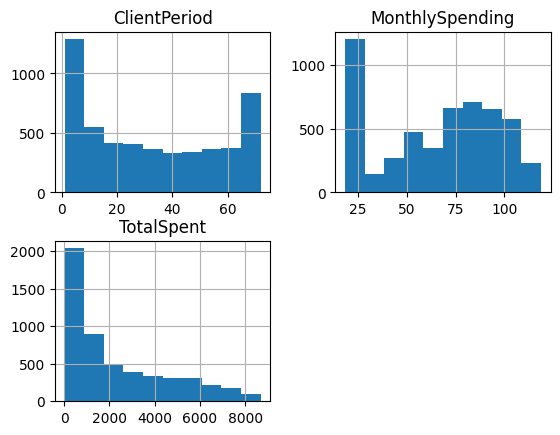

In [29]:
data[num_cols].hist()
plt.show()

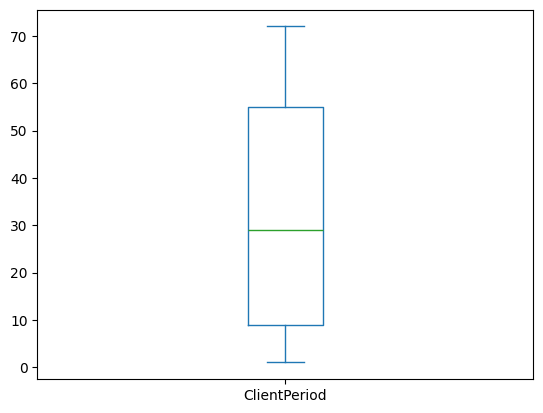

In [30]:
data['ClientPeriod'].plot.box()
plt.show()

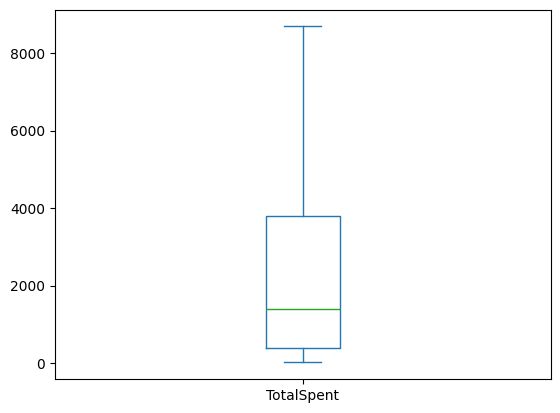

In [31]:
data['TotalSpent'].plot.box()
plt.show()

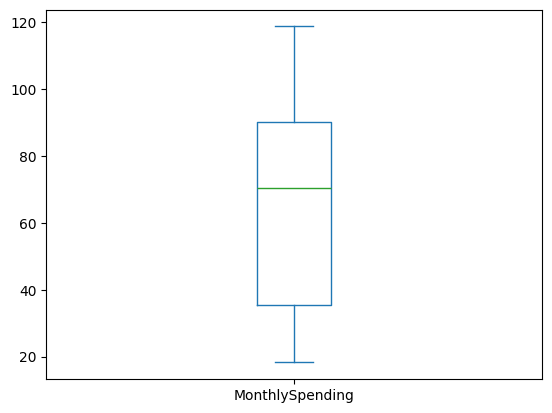

In [32]:
data['MonthlySpending'].plot.box()
plt.show()

In [33]:
data[num_cols].describe()

,ClientPeriod,MonthlySpending,TotalSpent
count,5273.000000,5273.000000,5273.000000
mean,32.452304,64.956770,2291.390461
std,24.534723,30.177911,2269.014233
min,1.000000,18.250000,18.800000
25%,9.000000,35.500000,401.100000
50%,29.000000,70.450000,1410.250000
75%,55.000000,90.050000,3807.350000
max,72.000000,118.750000,8684.800000


Выбросов ни в одной из численных перменных нет.

In [34]:
for col in cat_cols:
  display(data[col].value_counts())

,count
Sex,
Male,2651
Female,2622


,count
IsSeniorCitizen,
0,4431
1,842


,count
HasPartner,
No,2704
Yes,2569


,count
HasChild,
No,3676
Yes,1597


,count
HasPhoneService,
Yes,4754
No,519


...

,count
HasOnlineTV,
No,2098
Yes,2038
No internet service,1137


,count
HasMovieSubscription,
No,2077
Yes,2059
No internet service,1137


,count
HasContractPhone,
Month-to-month,2920
Two year,1272
One year,1081


,count
IsBillingPaperless,
Yes,3145
No,2128


,count
PaymentMethod,
Electronic check,1786
Mailed check,1188
Bank transfer (automatic),1157
Credit card (automatic),1142


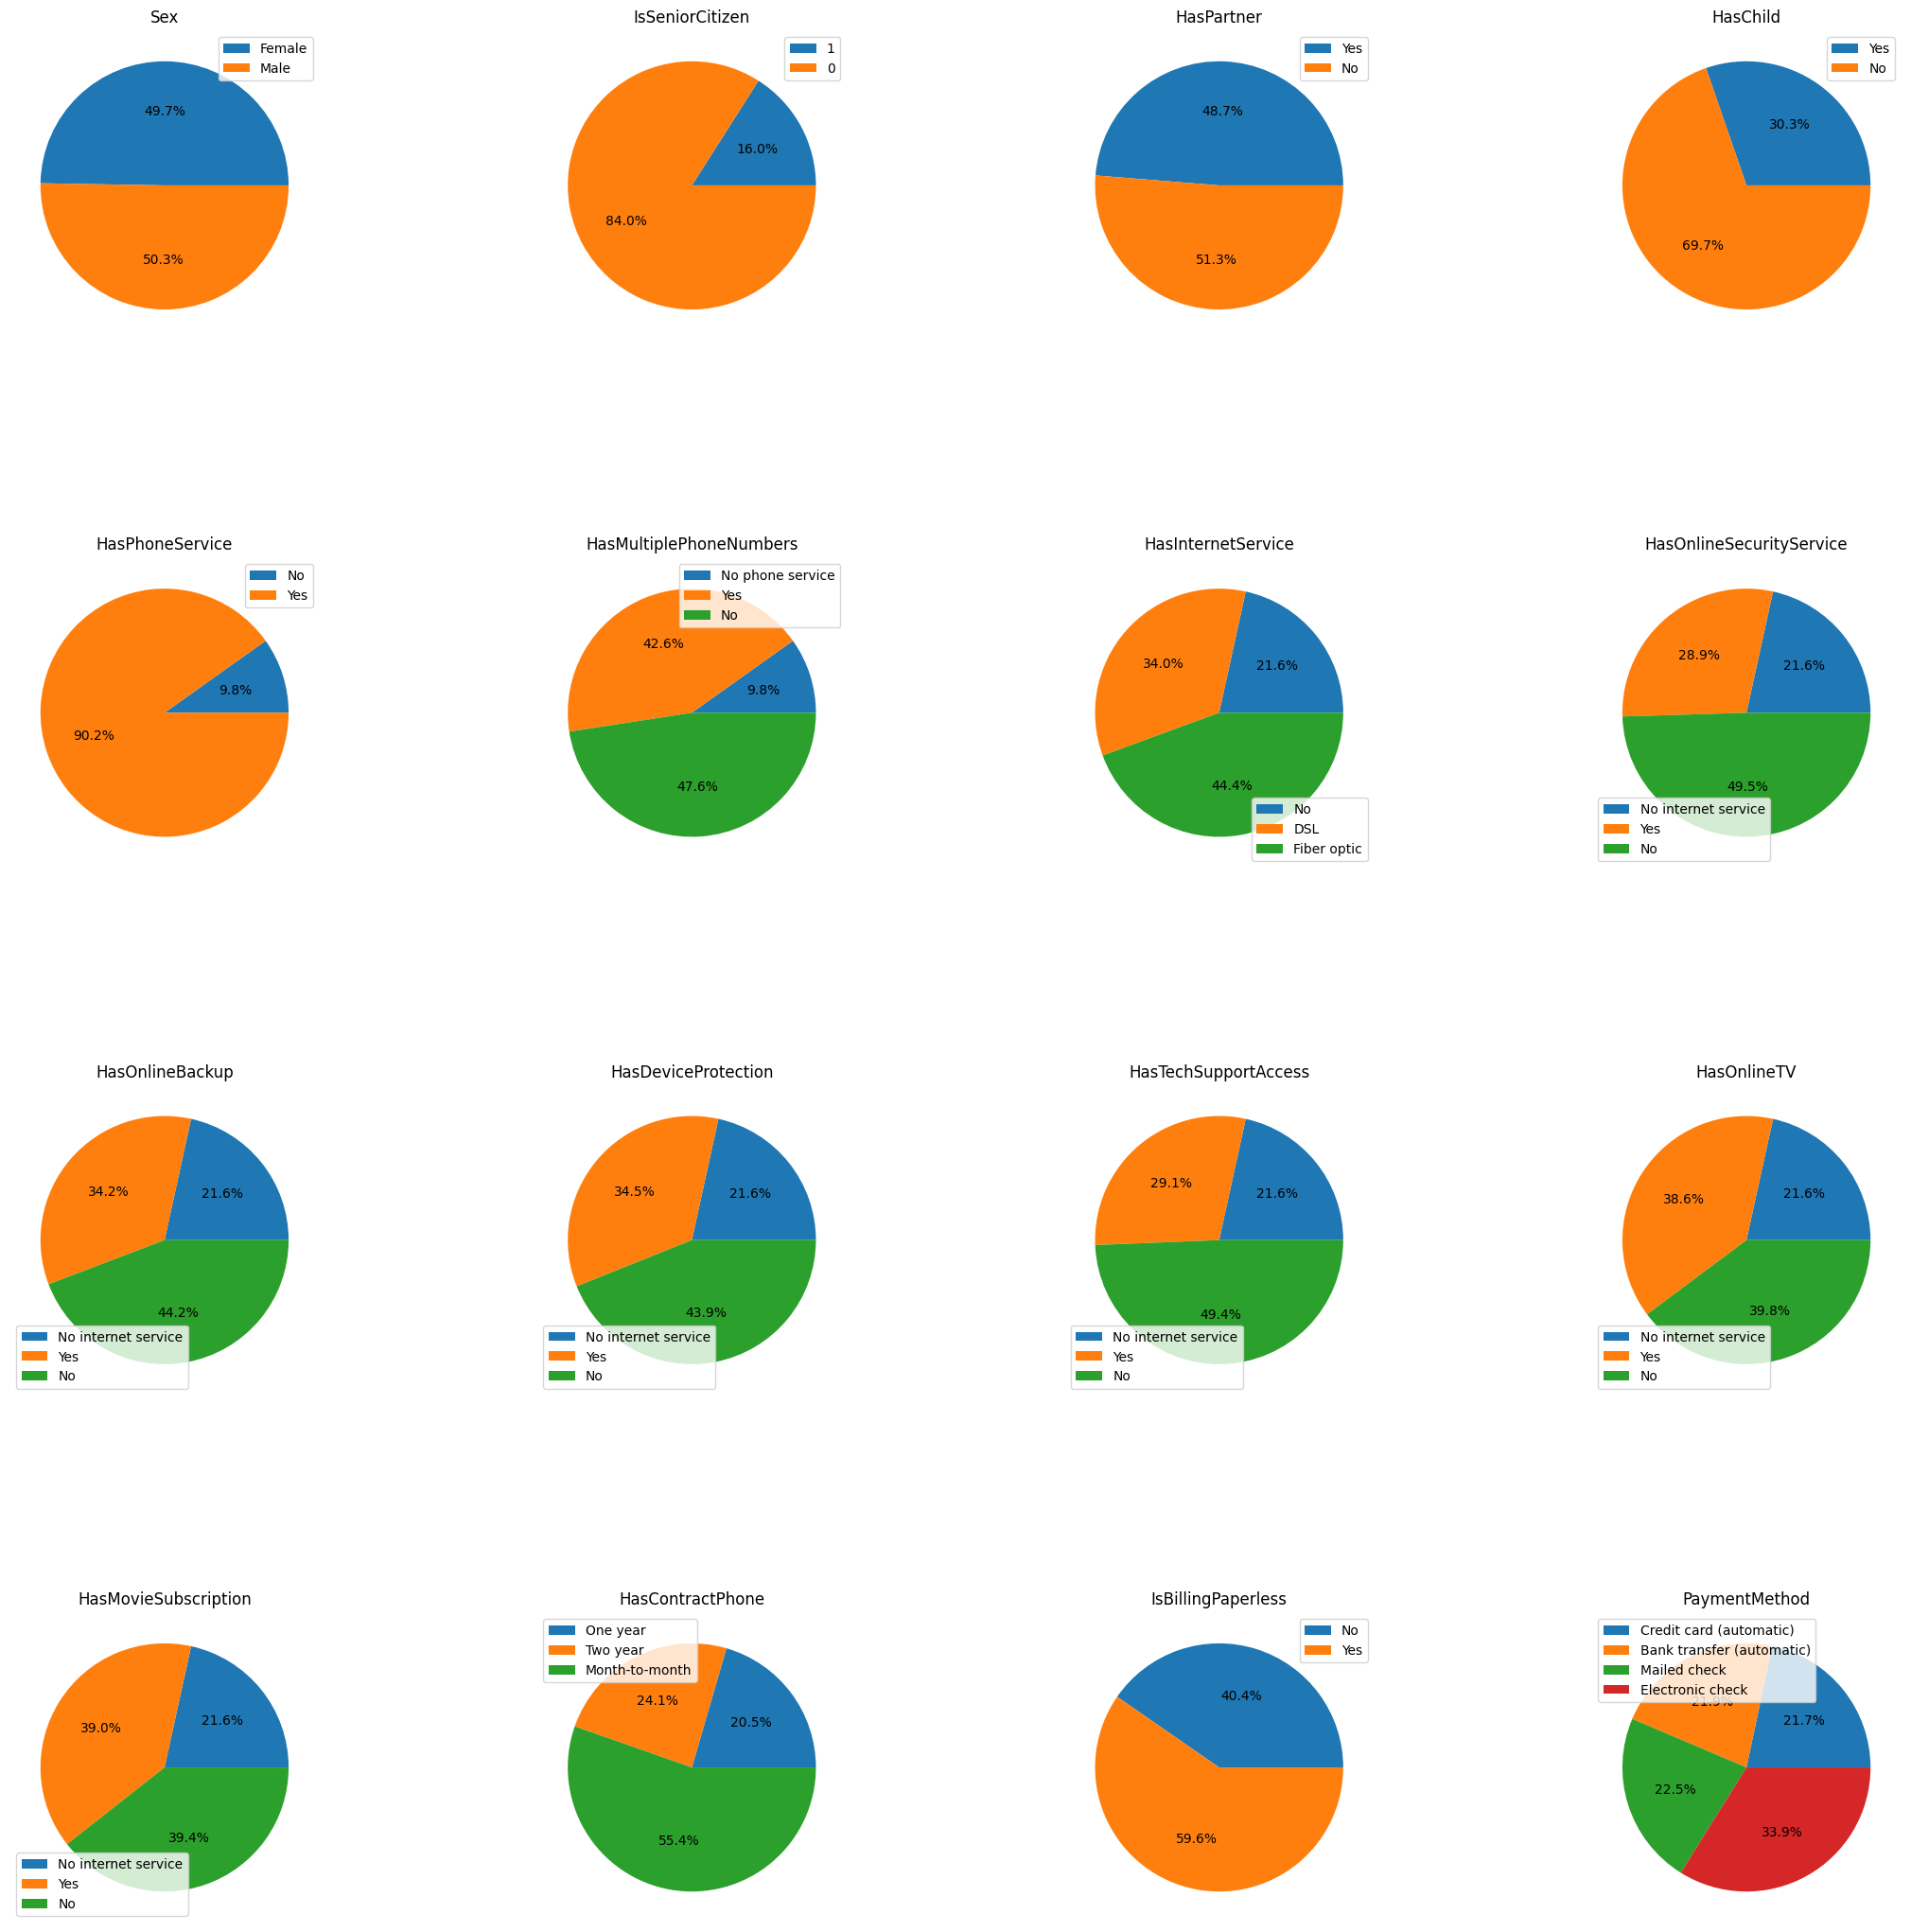

In [35]:
fig = plt.figure(0,figsize=(7.5,7.5))
fig.set_figheight(25)
fig.set_figwidth(25)
plots = []
for i in range(4):
    for j in range(4):
        ax = plt.subplot2grid((4,4), (i,j))
        ax.pie(data[cat_cols[i*4+j]].value_counts().reset_index().sort_values(by=['count'])['count'], autopct='%1.1f%%')
        ax.set_title(cat_cols[i*4+j])
        ax.legend(data[cat_cols[i*4+j]].value_counts().reset_index().sort_values(by=['count'])[cat_cols[i*4+j]].to_list())

plt.subplots_adjust(left=0.1, right=0.9,
                    top=0.9, bottom=0.1,
                    wspace=0.7, hspace=0.7)

plt.show()

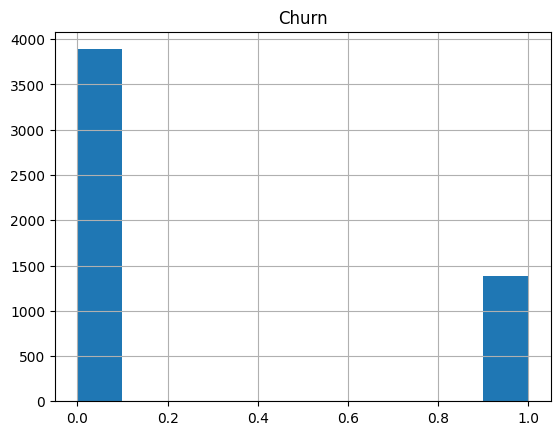

In [36]:
data['Churn'].hist()
plt.title('Churn')
plt.show()

In [37]:
data[data['Churn'] == 0]['Churn'].count() / data[data['Churn'] == 1]['Churn'].count()

np.float64(2.809971098265896)

Есть небольшой дисбаланс, но классы различаются в почти три раза по количеству, поэтому оставим, как есть.

## Применение моделей

In [38]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [39]:
data_new = data.copy()
data_new.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.20,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.90,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570.00,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [40]:
lenc = LabelEncoder()

for col in cat_cols:
  test[col] = lenc.fit_transform(test[col])
  data_new[col] = lenc.fit_transform(data_new[col])

In [41]:
data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.20,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.90,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570.00,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [42]:
enc = OneHotEncoder(sparse_output=False)

encoded = enc.fit_transform(data_new[cat_cols])
test_encoded = enc.fit_transform(test[cat_cols])

In [43]:
encoded.shape

(5273, 43)

In [44]:
one_hot_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(cat_cols))

one_hot_test = pd.DataFrame(test_encoded, columns=enc.get_feature_names_out(cat_cols))

In [45]:
data_encoded = pd.concat([data_new[num_cols].reset_index(drop=True), one_hot_df.reset_index(drop=True)], axis=1)

test_ready = pd.concat([test[num_cols].reset_index(drop=True), one_hot_test.reset_index(drop=True)], axis=1)

In [46]:
X=data_encoded.values
y=data_new['Churn'].values

In [47]:
scaler = StandardScaler()
clf = LogisticRegression()

parameters={'logisticregression__C':[100,10,1,0.1,0.01,0.001]}
pipeline =  make_pipeline(scaler,clf)
grid_search = GridSearchCV(pipeline,param_grid = parameters, scoring = 'roc_auc',cv=5, refit=True)

grid_search.fit(X,y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [100, 10, 1, 0.1, 0.01,
                                                   0.001]},
             scoring='roc_auc')

In [48]:
scores_df = pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score')
scores_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.037940,0.002654,0.004272,0.000082,10.000,{'logisticregression__C': 10},0.861897,0.836733,0.834664,0.855277,0.835566,0.844827,0.011447,1
0,0.049587,0.019615,0.004404,0.000211,100.000,{'logisticregression__C': 100},0.861944,0.836784,0.834612,0.855305,0.835426,0.844814,0.011491,2
2,0.036743,0.003889,0.004284,0.000120,1.000,{'logisticregression__C': 1},0.861763,0.836450,0.834673,0.855701,0.835380,0.844793,0.011555,3
3,0.027214,0.003200,0.005751,0.002821,0.100,{'logisticregression__C': 0.1},0.860203,0.835248,0.834232,0.856013,0.833772,0.843894,0.011691,4
4,0.021907,0.001032,0.004210,0.000049,0.010,{'logisticregression__C': 0.01},0.856839,0.832125,0.832084,0.856777,0.830822,0.841729,0.012321,5
5,0.021031,0.006967,0.004524,0.000402,0.001,{'logisticregression__C': 0.001},0.851085,0.823935,0.827105,0.855617,0.827361,0.837021,0.013465,6


In [49]:
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best cross-validation score: 0.84


In [50]:
best_row = scores_df.iloc[0,:]

In [51]:
best_param = best_row['param_logisticregression__C']

In [52]:
best_param

np.float64(10.0)

In [53]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.3 MB/s eta 0:00:00


In [54]:
import catboost

In [55]:
categories = np.array([3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18])

In [56]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns={'Churn'}).values,data['Churn'].values,train_size=0.8,random_state=42)

In [57]:
boost = catboost.CatBoostClassifier(n_estimators = 200, logging_level='Silent', cat_features = categories, eval_metric = 'AUC')

boost.grid_search({'l2_leaf_reg': np.linspace(0, 1, 20)}, X=X_train, y=y_train,plot=True, refit=True, verbose=False)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Metric AUC is not calculated on train by default. To calculate

{'params': {'l2_leaf_reg': 0.15789473684210523},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
               47,
  

In [58]:
y_train_predicted = boost.predict_proba(X_train)[:, 1]
y_test_predicted = boost.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import roc_auc_score, roc_curve

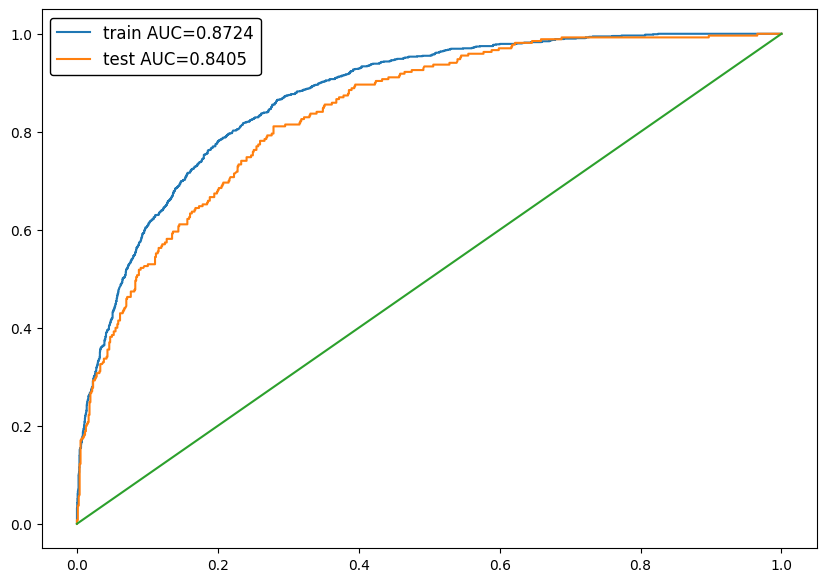

In [60]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

CatBoost получается сравним с линейной регрессией по качеству предсказаний: у обеих моделей качество примерно 0.84.

In [61]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv',index_col='Id')

submission['Churn'] = grid_search.predict(test_ready.values)
submission.to_csv('./my_submission.csv')